# MODEL IMPLEMENTATION - PART A

### Dataset Ingestion + Cleaning

In [11]:
import pandas as pd
import re

# Loading the dataset
df = pd.read_csv('2021-2025_games_clean.csv')
print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

def time_to_seconds(t):
    if not isinstance(t, str):
        return None
    # Extract only digits and colons (ignore text like "OT", "PT34M52S", etc.)
    cleaned = re.findall(r"[0-9:]+", t)
    if not cleaned:
        return None

    cleaned = cleaned[0]  # first match
    parts = cleaned.split(":")

    # Handling MM:SS
    if len(parts) == 2:
        m, s = parts
        return int(m)*60 + int(s)

    # Handling MM:SS:00
    if len(parts) == 3:
        m, s, n = parts
        return int(m)*60 + int(s)
    return None
# Applying it to home/away possession time - same as Milestone 2:
df['h_poss_time_sec'] = df['h_poss_time'].apply(time_to_seconds)
df['a_poss_time_sec'] = df['a_poss_time'].apply(time_to_seconds)

model_df = pd.DataFrame({'total_yards': df['h_total_yards'],
    'points': df['home_points'],
    'turnovers': df['h_turnovers'],
    'possession_time': df['h_poss_time_sec'],
    'penalty_yards': df['h_penalty_yards'],
    'win': (df['home_points'] > df['away_points']).astype(int)})

model_df = model_df.dropna()

print("\nModeling dataset created!")
print("Shape:", model_df.shape)
model_df.head()


Dataset loaded successfully!
Shape: (1359, 54)

Modeling dataset created!
Shape: (1359, 6)


,total_yards,points,turnovers,possession_time,penalty_yards,win
0,458,16,3,2129,97,0
1,357,14,2,1748,43,0
2,285,16,1,1993,51,1
3,342,22,0,1769,147,1
4,355,16,1,1521,69,1


### K MEANS CLUSTERING

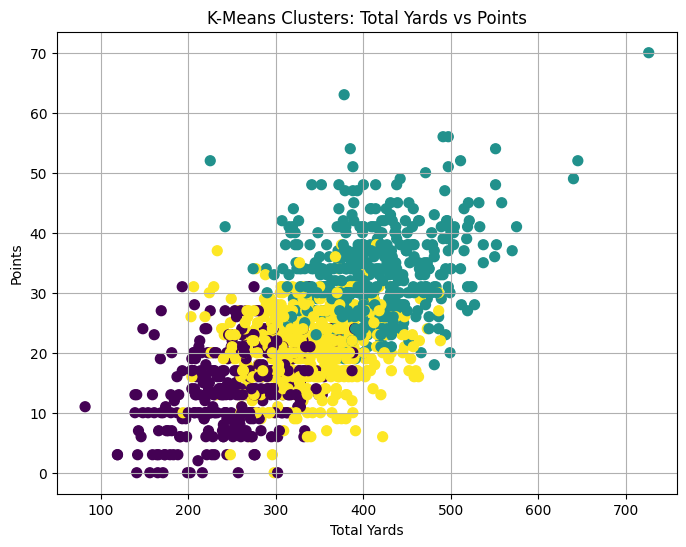

Silhouette Score: 0.20039921094937352


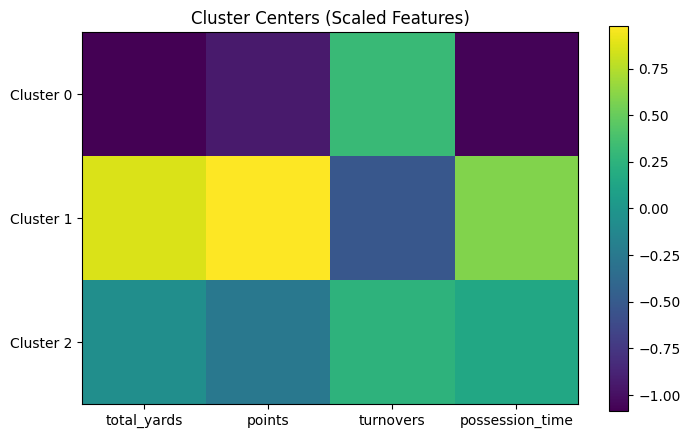

In [12]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Selecting features
cluster_features = model_df[['total_yards', 'points', 'turnovers', 'possession_time']]

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_features)

# Fitting K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_scaled)
model_df['kmeans_cluster'] = labels

# Visualization of Yards vs Points
plt.figure(figsize=(8,6))
plt.scatter(model_df['total_yards'], model_df['points'], c=model_df['kmeans_cluster'], cmap='viridis', s=50)
plt.title("K-Means Clusters: Total Yards vs Points")
plt.xlabel("Total Yards")
plt.ylabel("Points")
plt.grid(True)
plt.show()

# Silhouette Score
print("Silhouette Score:", silhouette_score(X_scaled, labels))

# Visualization of Cluster Centers
centers = kmeans.cluster_centers_
plt.figure(figsize=(8,5))
plt.imshow(centers, cmap='viridis')
plt.colorbar()
plt.xticks(range(4), ['total_yards','points','turnovers','possession_time'])
plt.yticks(range(3), ['Cluster 0','Cluster 1','Cluster 2'])
plt.title("Cluster Centers (Scaled Features)")
plt.show()

#### K-Means Clustering - Interpretation

Silhouette Score  

Measures how well each game fits within its assigned cluster.  
- Ranges from -1 to 1.
- Higher = better separation between clusters .
- Values above 0.5 indicate strong, meaningful clusters.

> Output -

1. Cluster Scatter Plot -

Shows how games group based on:
- Total yards  
- Points  
- Turnovers  
- Possession time  

Each color represents a different cluster of similar game performances.

2. Cluster Centers Heatmap

Displays the “average profile” of each cluster after scaling because our averages are in scaled units, not original units.  

Helps interpret what makes each cluster unique. (e.g., high‑yardage games, turnover-heavy games, etc.).

### Hierarchial Clustering

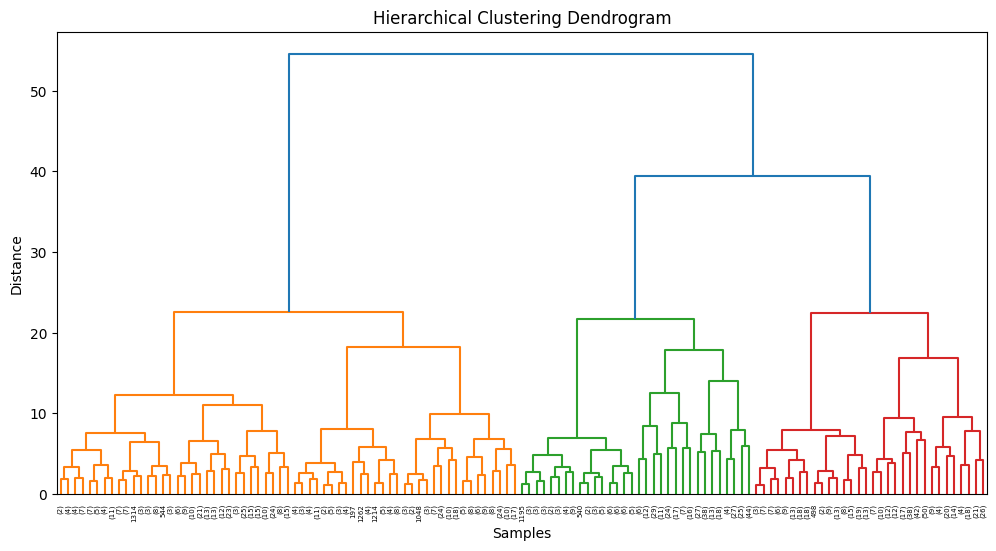

Silhouette Score (Hierarchical): 0.2324844818671387


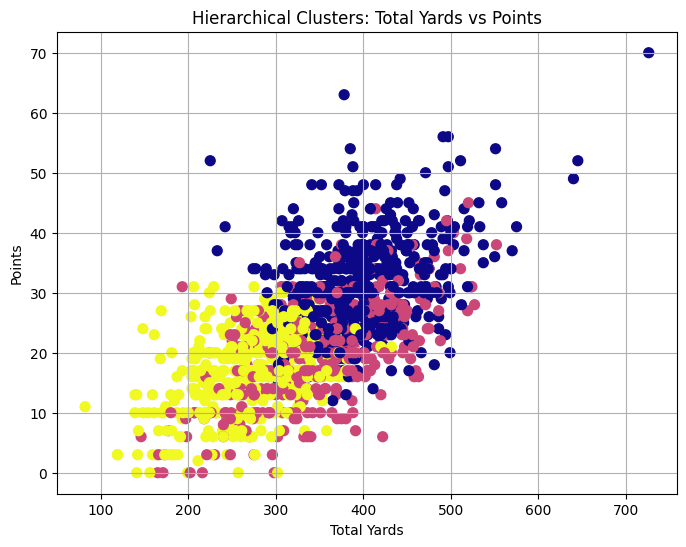

In [13]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_features)

# Linkage matrix - this builds our hierarchial clustering dendrogram
Z = linkage(X_scaled, method='ward')
#this means, we are merging clusters in a way that minimizes the increase in total within-cluster variance

# Dendrogram
plt.figure(figsize=(12,6))
dendrogram(Z,truncate_mode='level',p=6,color_threshold=0.7 * max(Z[:,2]))
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

# Assign clusters
labels_h = fcluster(Z, t=3, criterion='maxclust')
model_df['hier_cluster'] = labels_h

# Silhouette Score
print("Silhouette Score (Hierarchical):", silhouette_score(X_scaled, labels_h))

# Visualization: Yards vs Points
plt.figure(figsize=(8,6))
plt.scatter(model_df['total_yards'], model_df['points'], c=model_df['hier_cluster'], cmap='plasma',s=50)
plt.title("Hierarchical Clusters: Total Yards vs Points")
plt.xlabel("Total Yards")
plt.ylabel("Points")
plt.grid(True)
plt.show()

#### Hierarchical Clustering - Interpretation

> 1. Dendrogram -

A tree-like diagram showing how games merge into clusters step-by-step.  
- Large vertical jumps indicate natural cluster boundaries  
- Cutting the tree at a chosen height gives the final clusters

> 2. Silhouette Score -

Same meaning as K-Means:  
- Higher score = cleaner, more separated clusters

> 3. Cluster Scatter Plot -

Visualizes how hierarchical clusters group games based on yards and points.  
Useful for comparing with K-Means to see if both methods find similar patterns.

### LINEAR REGRESSION

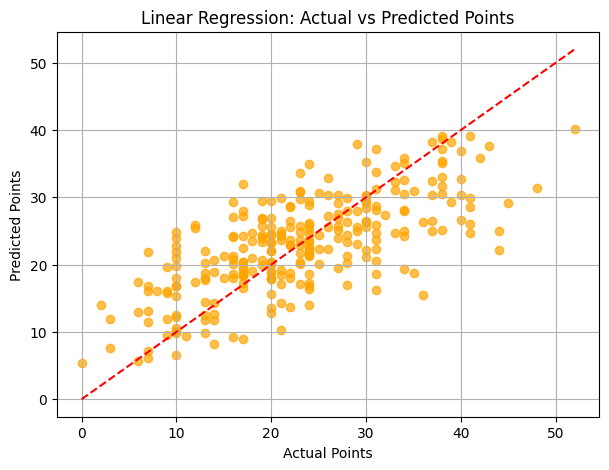

RMSE: 6.885309380235922
R² Score: 0.501991823819031


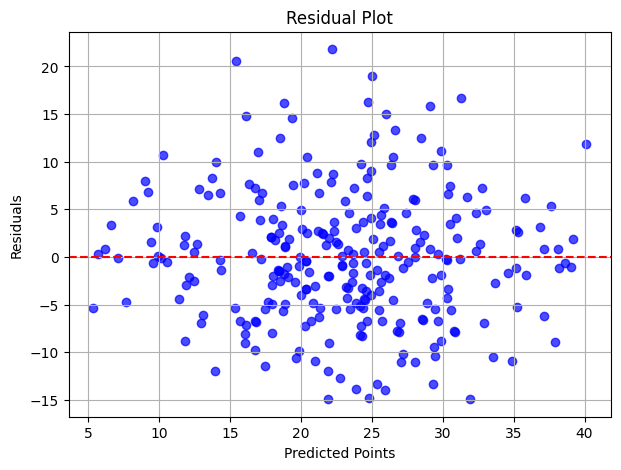

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Features & target
X = model_df[['total_yards', 'turnovers', 'possession_time', 'penalty_yards']]
y = model_df['points']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions
y_pred = lr.predict(X_test)

# Visualization: Actual vs Predicted
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred, alpha=0.7, color = 'orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Points")
plt.ylabel("Predicted Points")
plt.title("Linear Regression: Actual vs Predicted Points")
plt.grid(True)
plt.show()

# Evaluation
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² Score:", r2_score(y_test, y_pred))

# Visualization: Residual Plot
residuals = y_test - y_pred
plt.figure(figsize=(7,5))
plt.scatter(y_pred, residuals, alpha=0.7, color = 'blue')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Points")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True)
plt.show()

#### Linear Regression - Interpretation

> 1. RMSE (Root Mean Squared Error)

Average error between predicted and actual points.  
- Lower RMSE = better predictions.
- Represents “how many points off” the model is on average.

> 2. R² Score

Explains how much of the variation in points is explained by the features.  
- Ranges from 0 to 1.
- Higher R² = better fit  
- Example: R² = 0.65 means “65% of scoring variation is explained”.

> 3. Actual vs Predicted Plot

Shows how close predictions are to real game scores.  
Points near the diagonal line = accurate predictions.

> 4. Residual Plot

Shows the errors (residuals) for each prediction.  
- Random scatter = good model  
- Patterns or curves = model is missing something

### LOGISTIC REGRESSION

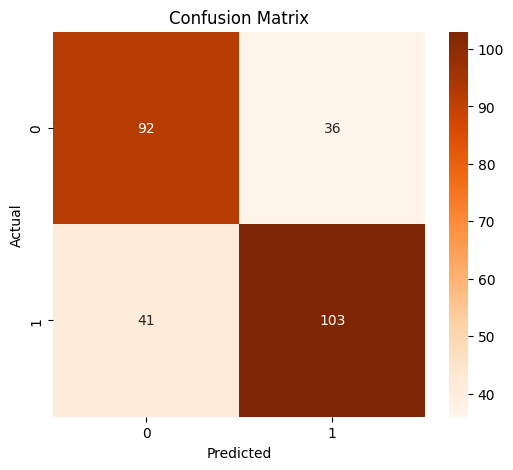

Accuracy: 0.7169117647058824
Precision: 0.7410071942446043
Recall: 0.7152777777777778
F1 Score: 0.7279151943462897
ROC-AUC: 0.8023003472222222


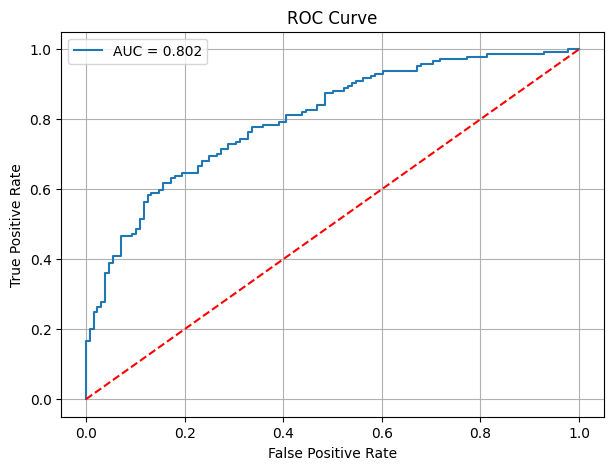

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix)
import seaborn as sns
import matplotlib.pyplot as plt

# Features & target
X = model_df[['total_yards', 'turnovers', 'possession_time', 'penalty_yards']]
y = model_df['win']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Fit model
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

# Predictions
y_pred = logreg.predict(X_test)
y_prob = logreg.predict_proba(X_test)[:, 1]

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], 'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

#### Logistic Regression - Interpretation

> 1. Accuracy

Percentage of total predictions that were correct.  
Good for balanced datasets.

> 2. Precision

Of all predicted wins, how many were actually wins?  
Measures reliability of win predictions.

> 3. Recall  

Of all actual wins, how many did the model correctly identify?  
Measures ability to detect wins.

> 4. F1 Score

Balance between precision and recall.  
Useful when classes are imbalanced.

> 5. ROC Curve

Plots True Positive Rate vs False Positive Rate across all thresholds.  
Higher curve = better ability to separate wins from losses.

> 6. AUC (Area Under the ROC Curve)

Single score summarizing the ROC curve.  
- 0.5 = random guessing  
- 1.0 = perfect classifier  
Represents the probability the model ranks a winning team higher than a losing team.

> 7. Confusion Matrix

Breakdown of predictions:  
- **TP**: predicted win, actual win  
- **TN**: predicted loss, actual loss  
- **FP**: predicted win, actual loss  
- **FN**: predicted loss, actual win  
Shows exactly where the model succeeds or fails.

### Support Vector Machine

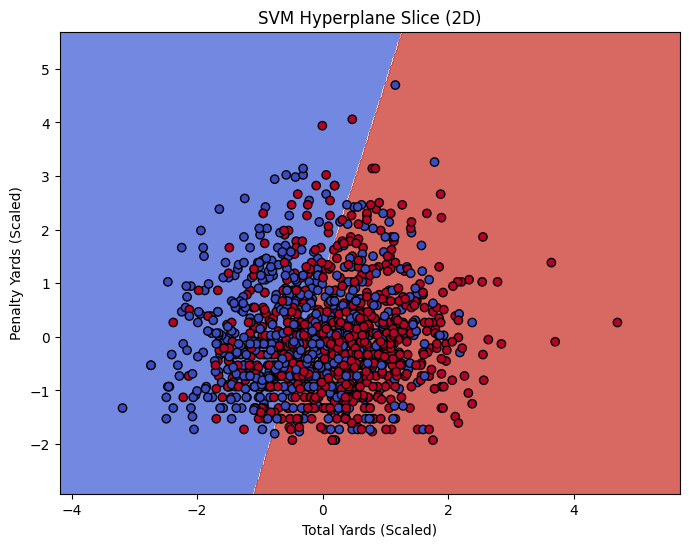

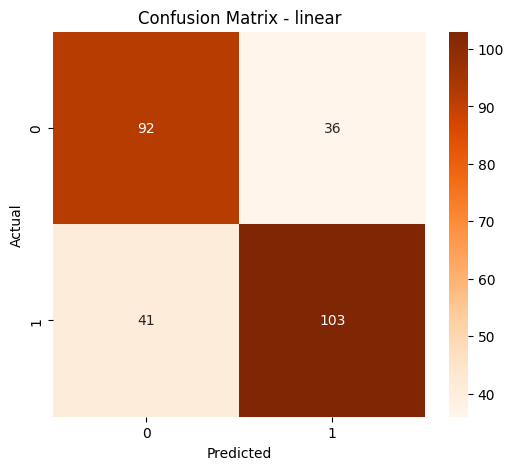

              precision    recall  f1-score   support

           0       0.69      0.72      0.70       128
           1       0.74      0.72      0.73       144

    accuracy                           0.72       272
   macro avg       0.72      0.72      0.72       272
weighted avg       0.72      0.72      0.72       272



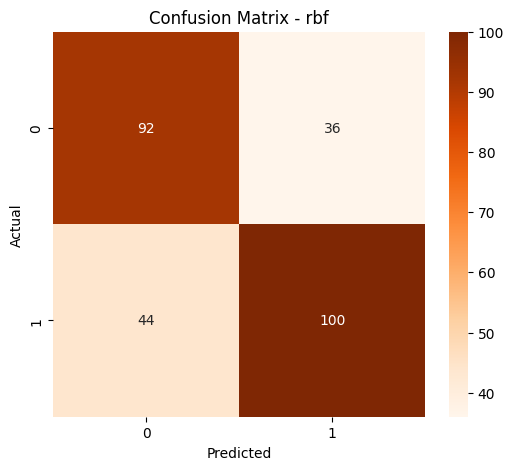

              precision    recall  f1-score   support

           0       0.68      0.72      0.70       128
           1       0.74      0.69      0.71       144

    accuracy                           0.71       272
   macro avg       0.71      0.71      0.71       272
weighted avg       0.71      0.71      0.71       272



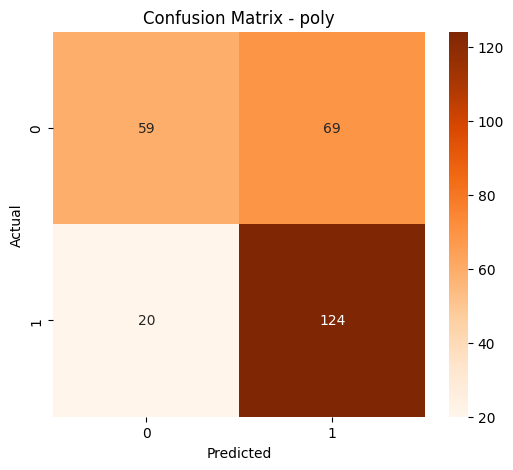

              precision    recall  f1-score   support

           0       0.75      0.46      0.57       128
           1       0.64      0.86      0.74       144

    accuracy                           0.67       272
   macro avg       0.69      0.66      0.65       272
weighted avg       0.69      0.67      0.66       272



In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

### FOR VISUALIZATION: Train a model on just two features ###
X_2D = model_df[['total_yards', 'penalty_yards']]
y_2D = model_df['win']

# Scale features
scaler_2D = StandardScaler()
X_2D_scaled = scaler_2D.fit_transform(X_2D)

svm_2D = SVC(kernel='linear', C=1.0)
svm_2D.fit(X_2D_scaled, y_2D)

# Create a mesh grid to plot the decision boundary
h = .02
x_min, x_max = X_2D_scaled[:, 0].min() - 1, X_2D_scaled[:, 0].max() + 1
y_min, y_max = X_2D_scaled[:, 1].min() - 1, X_2D_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# 3. Predict across the entire mesh
Z = svm_2D.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 4. Plot
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)
plt.scatter(X_2D_scaled[:, 0], X_2D_scaled[:, 1], c=y_2D, cmap=plt.cm.coolwarm, edgecolors='k')
plt.xlabel('Total Yards (Scaled)')
plt.ylabel('Penalty Yards (Scaled)')
plt.title('SVM Hyperplane Slice (2D)')
plt.show()


### Train model on 4 features ###
X = model_df[['total_yards', 'turnovers', 'possession_time', 'penalty_yards']]
y = model_df['win']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Fit model
for kernel in ("linear", "rbf", "poly"):
    svm_model = SVC(kernel=kernel, C=1.0, probability=True, random_state=42)
    svm_model.fit(X_train, y_train)

    # Predictions
    y_pred = svm_model.predict(X_test)
    y_prob = svm_model.predict_proba(X_test)[:, 1]

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
    plt.title(f"Confusion Matrix - {kernel}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Evaluation
    print(classification_report(y_test, y_pred))



### Random Forest

Accuracy: 0.76838
F1 Score: 0.76750


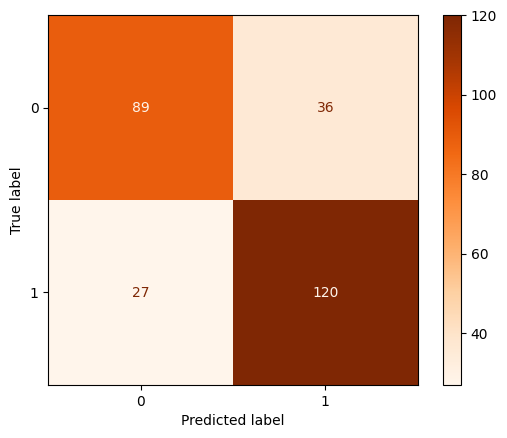

In [24]:
import pandas as pd
import re
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay


X = model_df[['total_yards', 'turnovers', 'possession_time', 'penalty_yards']]
y = model_df[['win']]
y = y.values.flatten()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

#X, y = make_classification(n_samples=1000, n_features=4,
#                           n_informative=2, n_redundant=0,
#                           random_state=0, shuffle=False)

clf = RandomForestClassifier(max_depth=4)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1score = f1_score(y_test, y_pred, average='weighted')
print(f'Accuracy: {accuracy:.5f}')
print(f"F1 Score: {f1score:.5f}")

cf_mat = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cf_mat,
                              display_labels=clf.classes_)
disp.plot(cmap='Oranges')
plt.show()